In [7]:
from google.colab import files
uploaded = files.upload()

Saving HR-Employee-Attrition.csv to HR-Employee-Attrition.csv


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from imblearn.over_sampling import SMOTE

In [9]:
df = pd.read_csv('HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [10]:
print("Shape:", df.shape)
print("\nColumns:\n", df.columns)
print("\nData Types:\n", df.dtypes)
print("\nSummary:\n", df.describe())

Shape: (1470, 35)

Columns:
 Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')

Data Types:
 Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
E

In [11]:
df.isnull().sum()

# Fill numeric with mean
for col in df.select_dtypes(include=np.number):
    df[col].fillna(df[col].mean(), inplace=True)

# Fill categorical with mode
for col in df.select_dtypes(include='object'):
    df[col].fillna(df[col].mode()[0], inplace=True)

In [12]:
df.drop_duplicates(inplace=True)

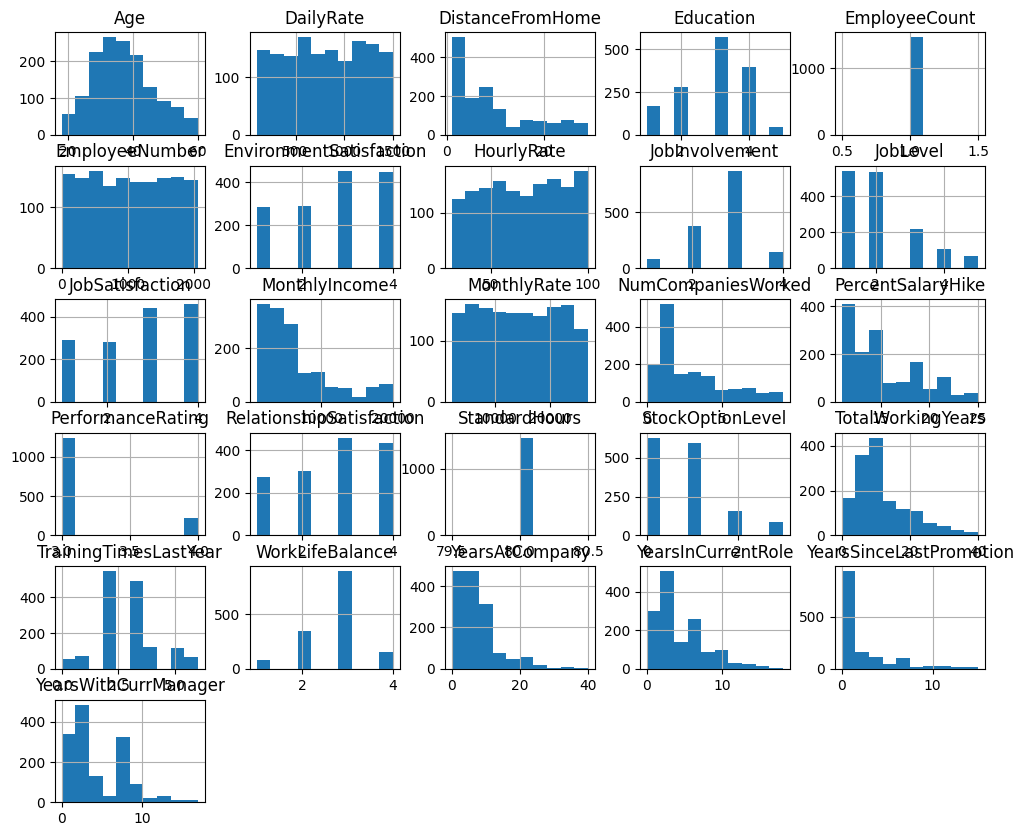

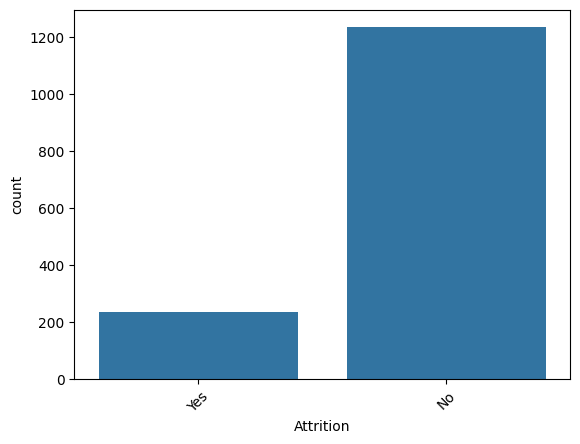

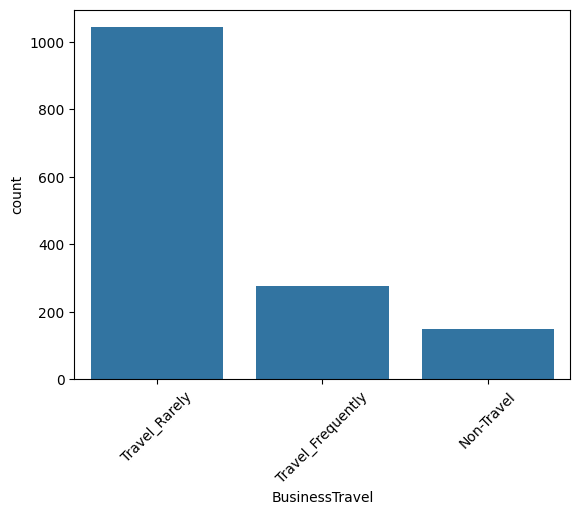

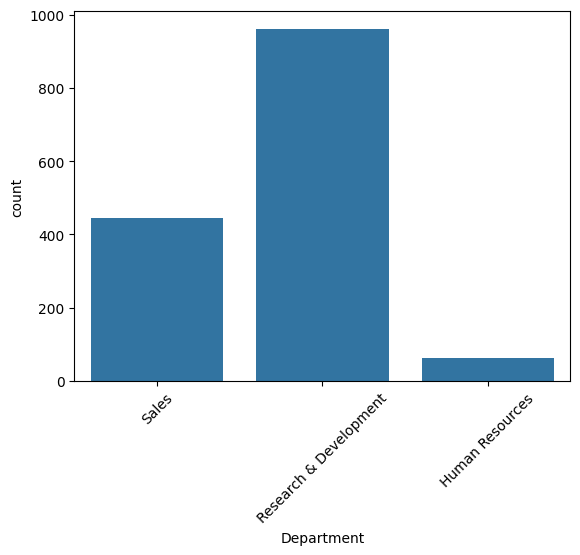

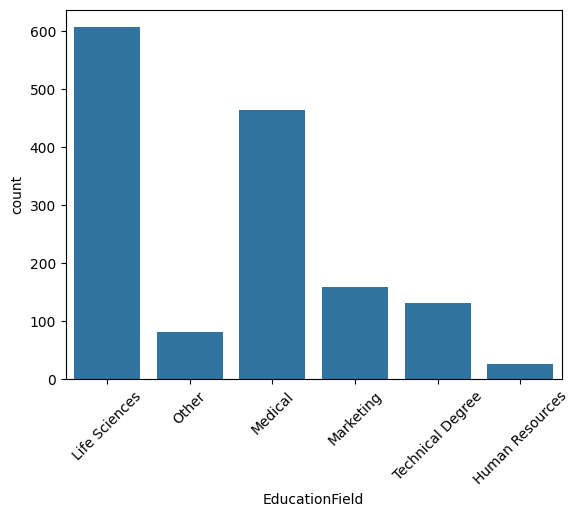

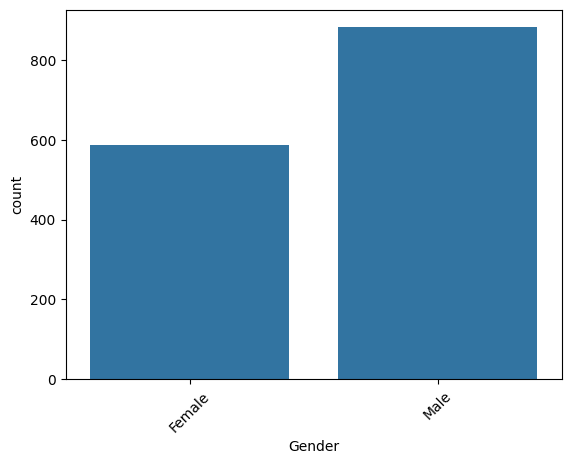

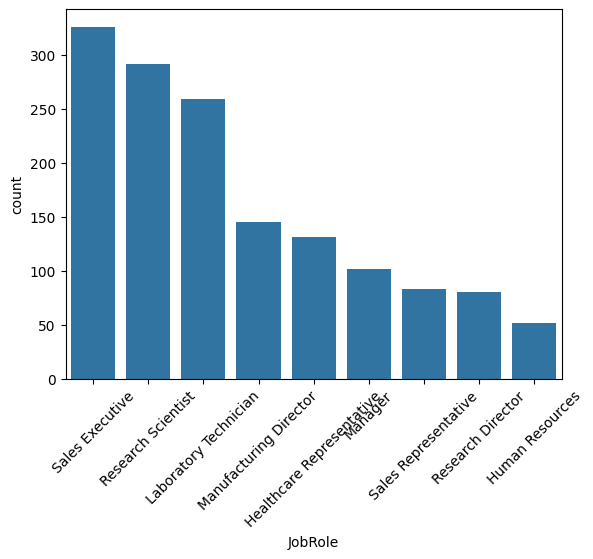

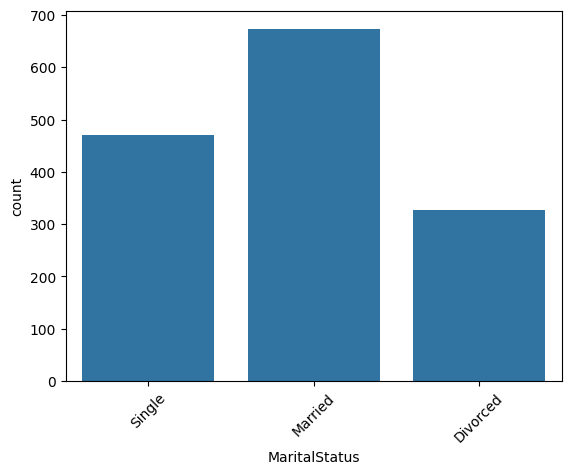

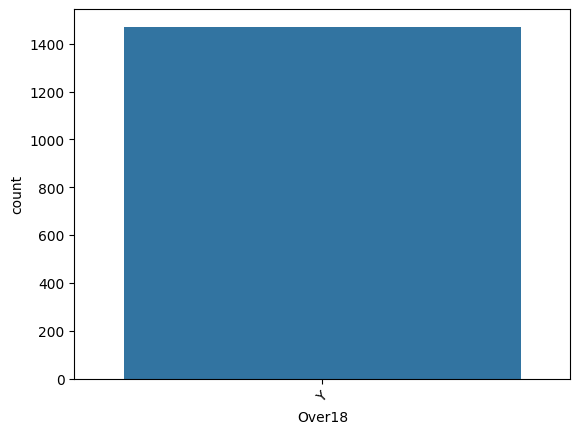

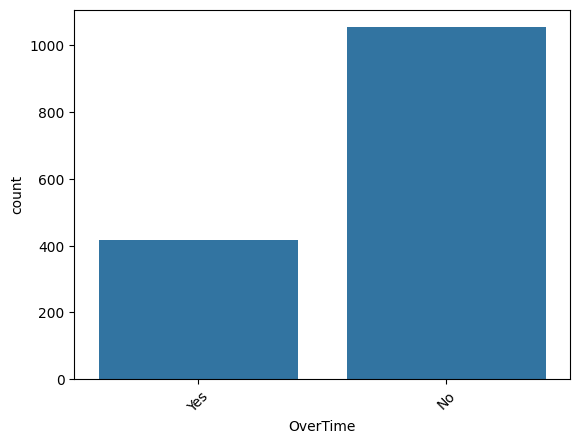

In [13]:
# Numerical
df.hist(figsize=(12,10))
plt.show()

# Categorical
for col in df.select_dtypes(include='object'):
    sns.countplot(x=col, data=df)
    plt.xticks(rotation=45)
    plt.show()

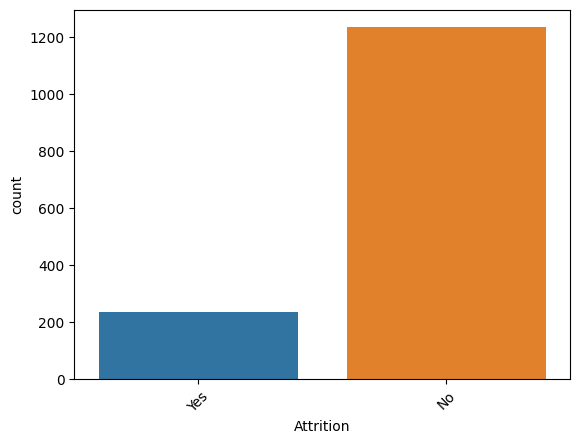

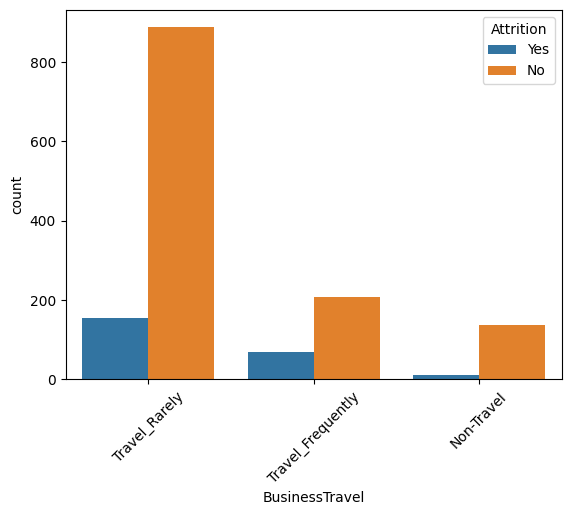

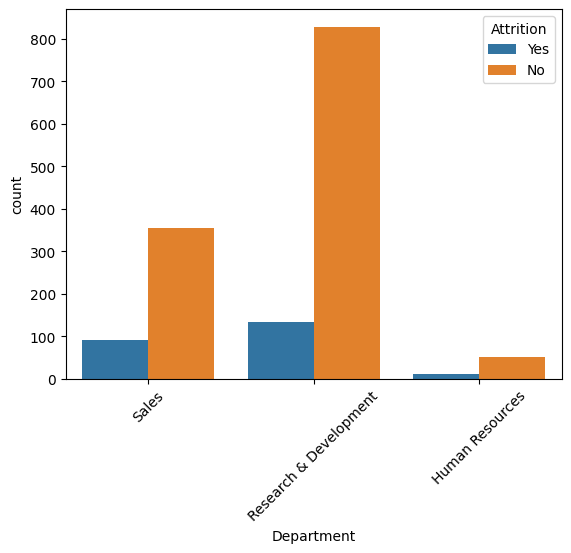

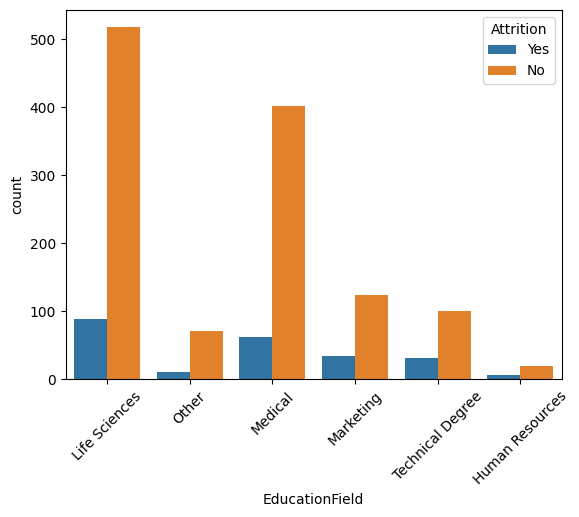

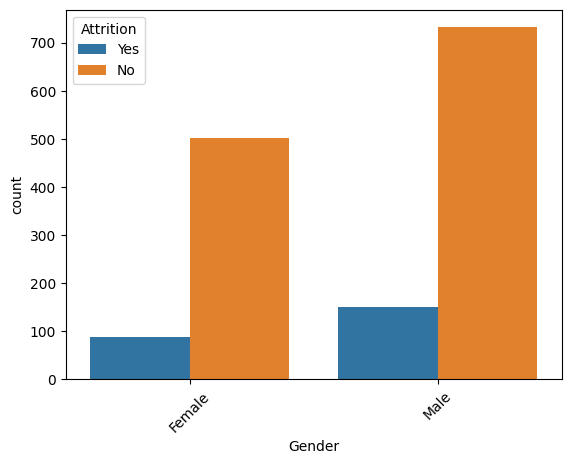

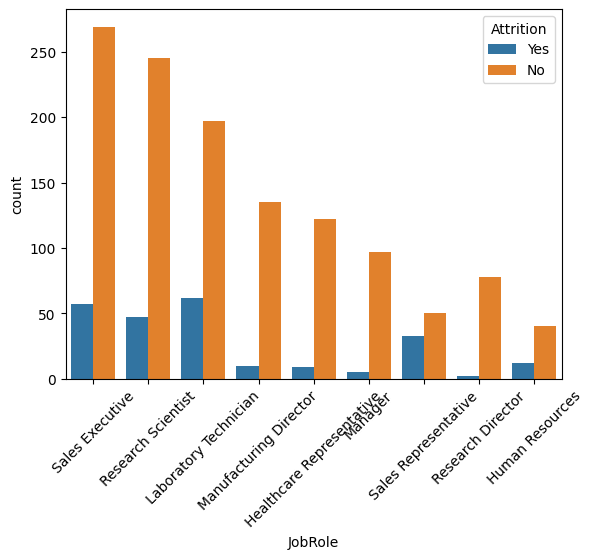

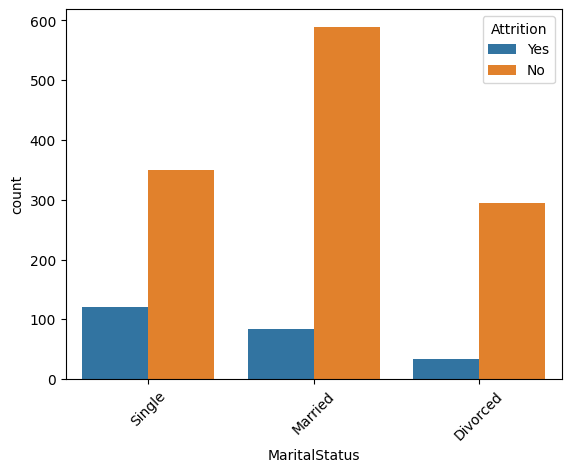

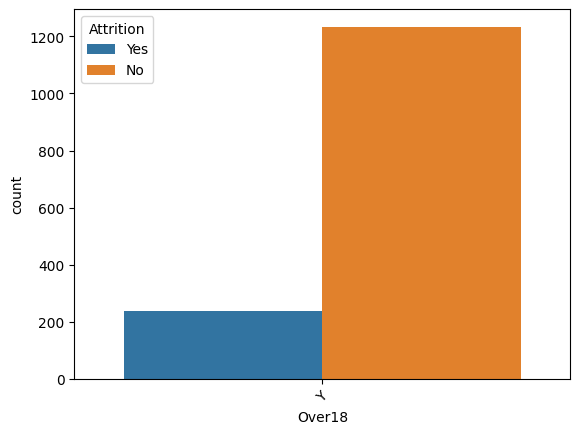

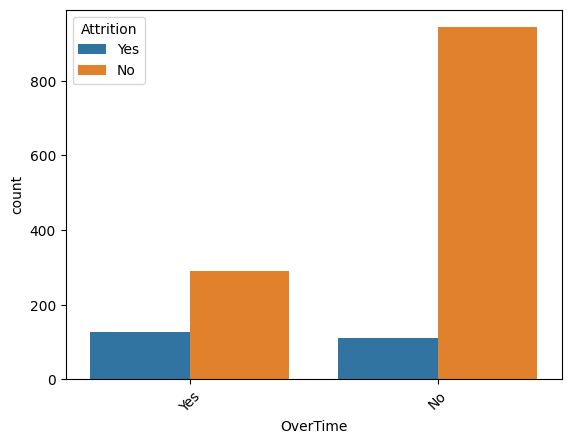

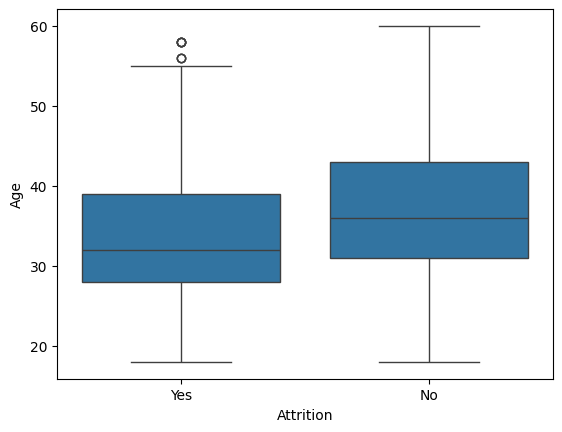

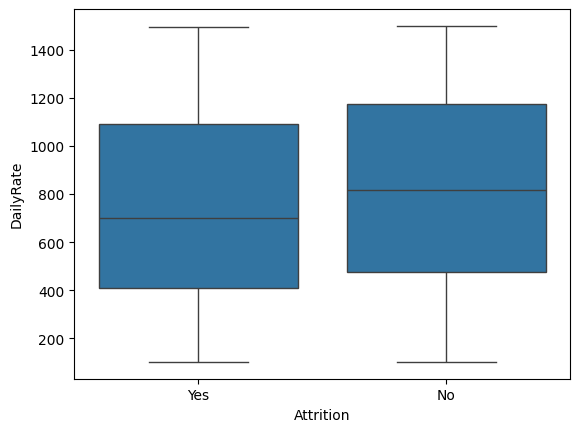

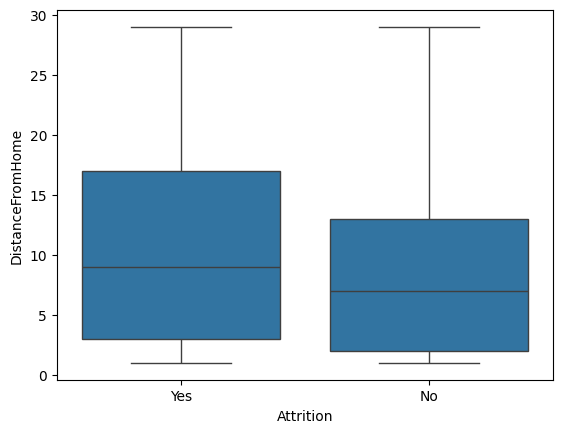

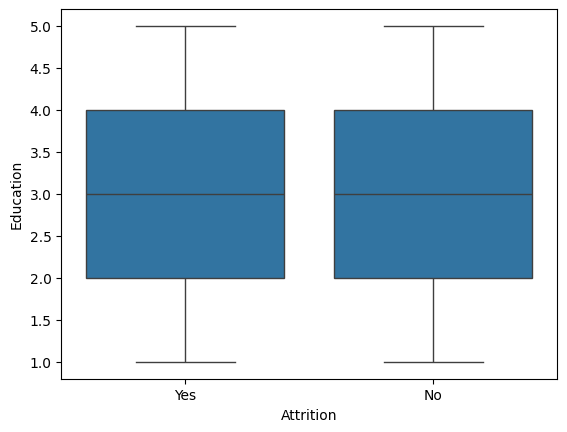

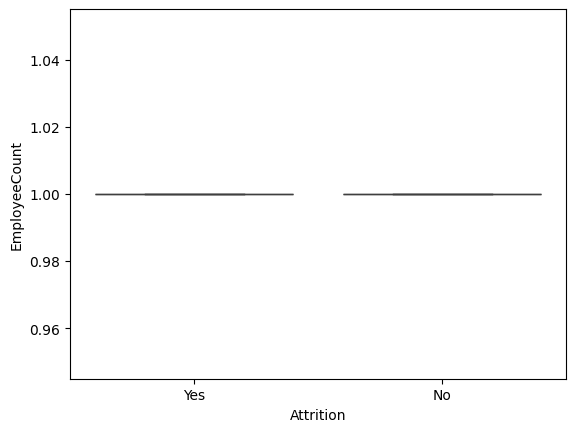

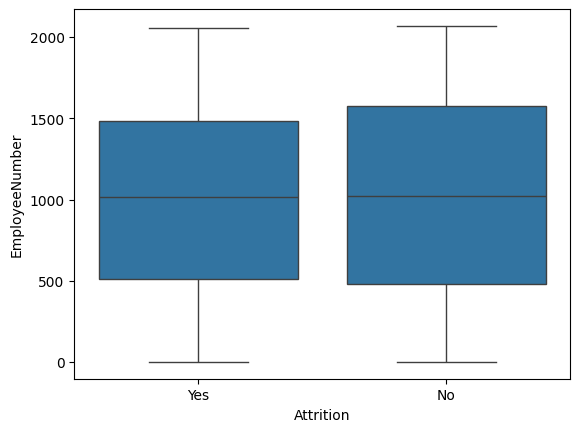

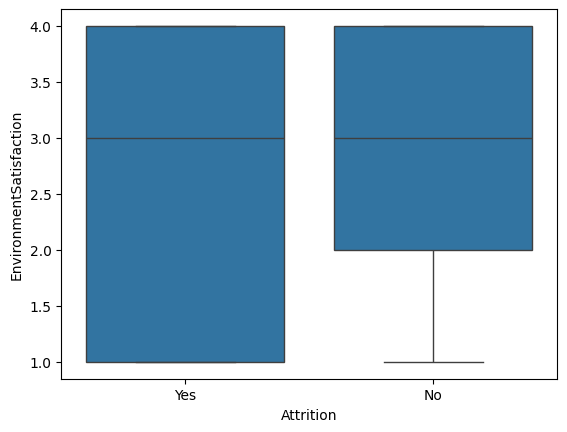

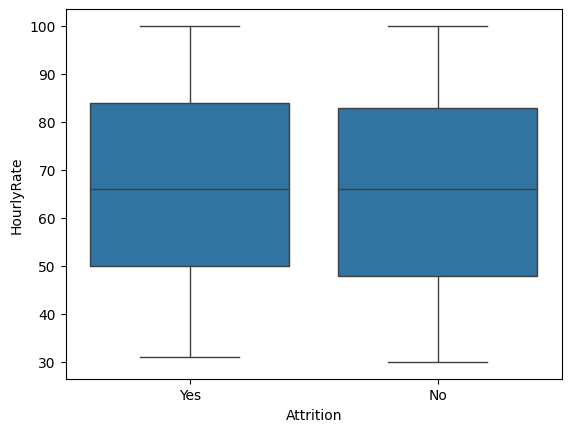

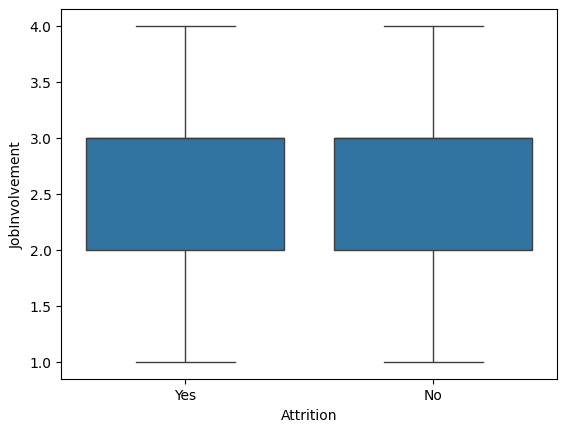

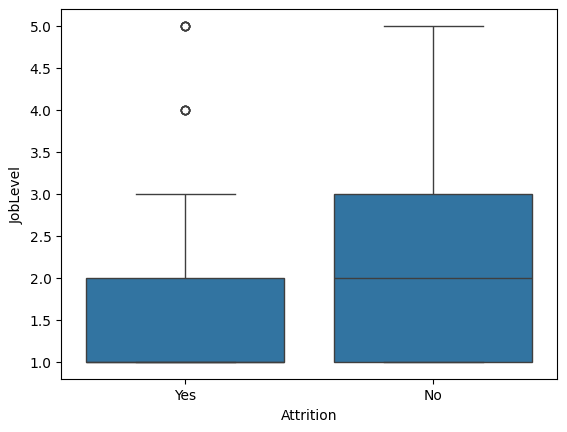

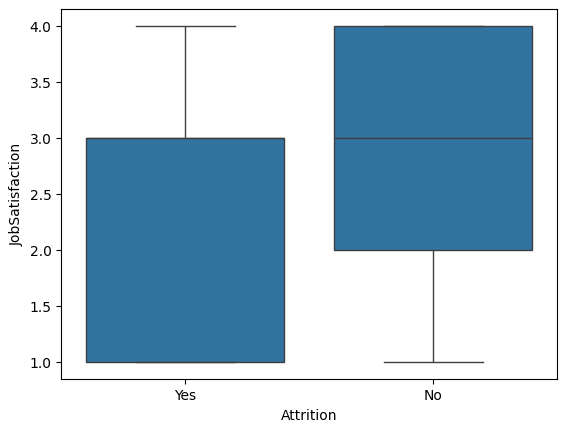

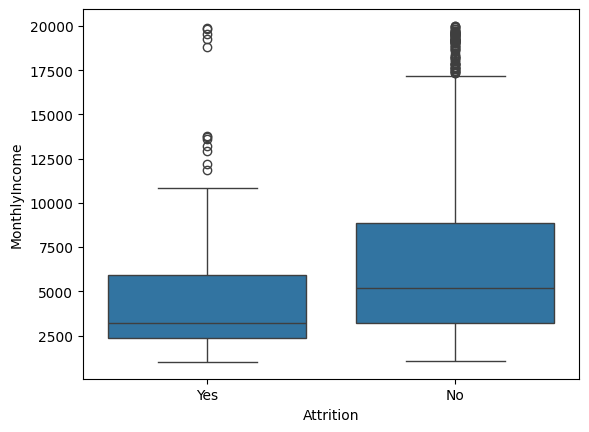

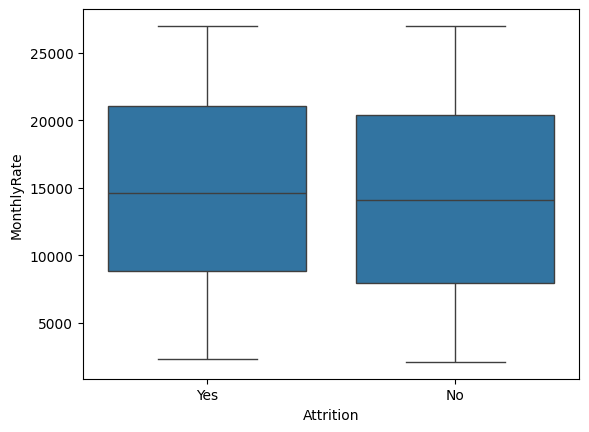

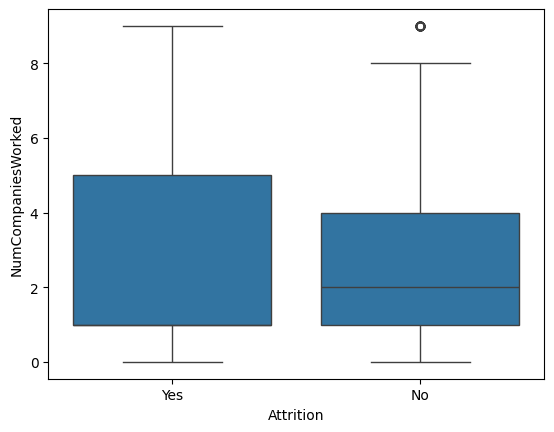

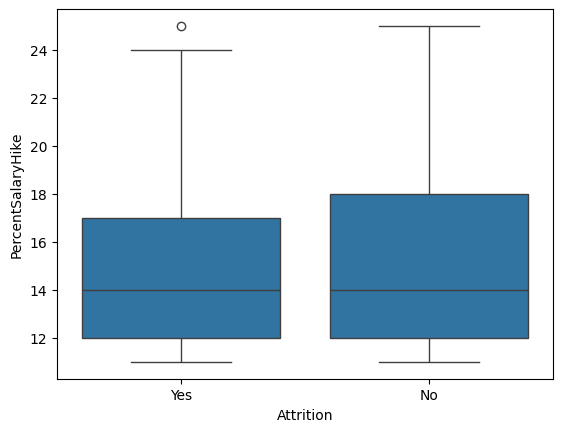

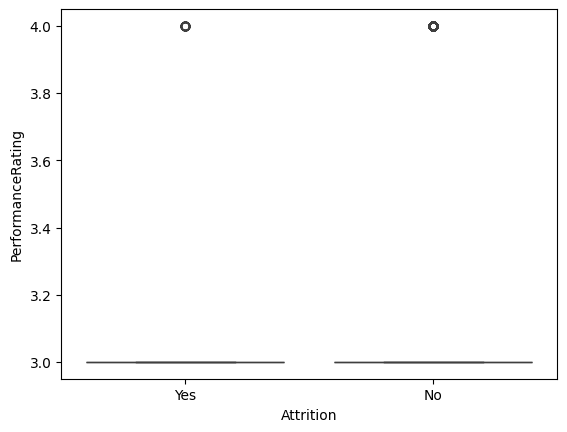

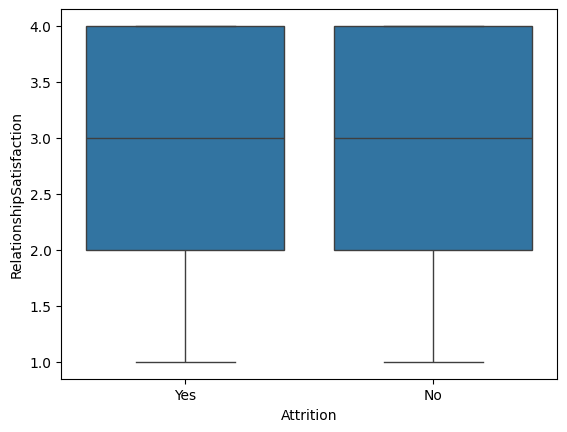

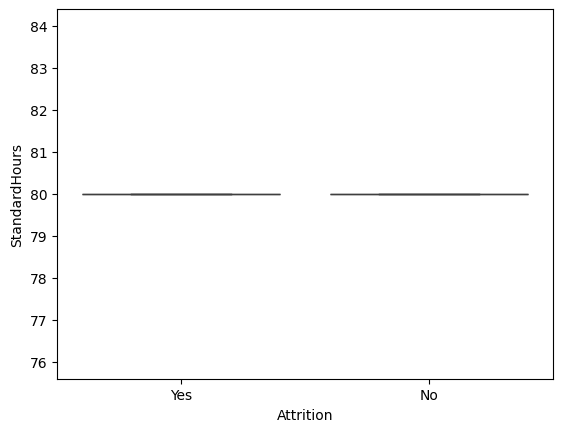

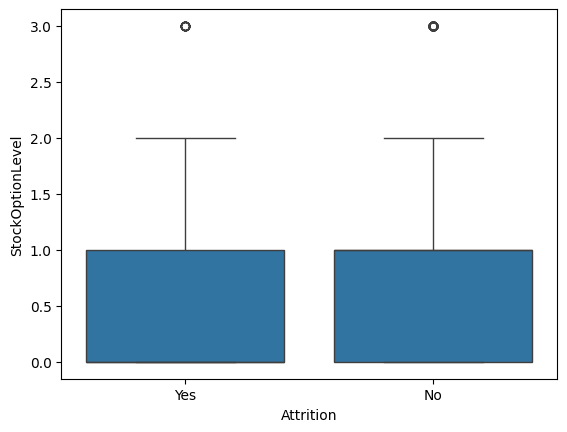

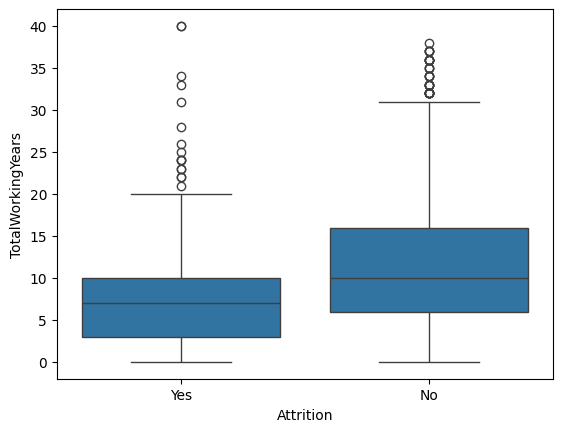

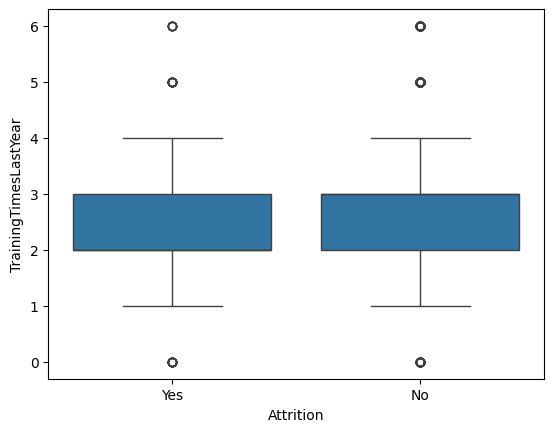

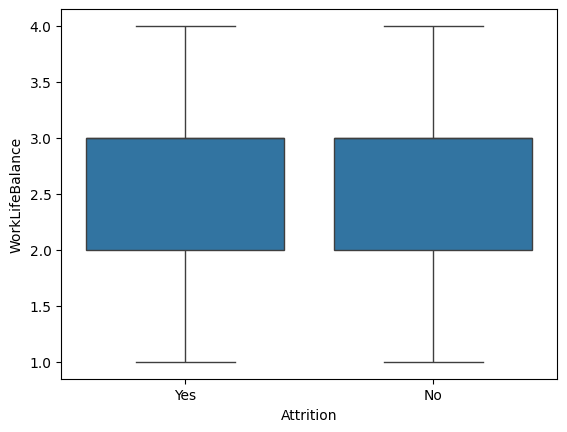

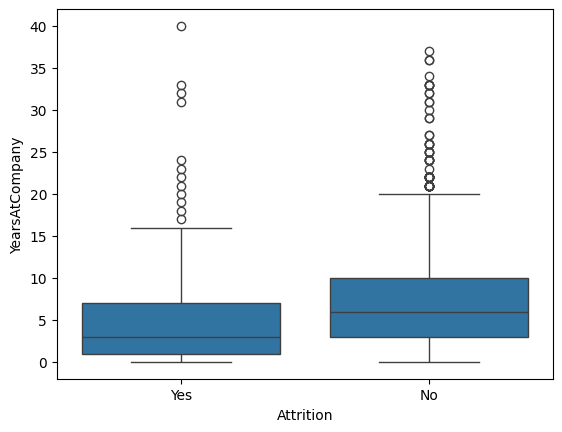

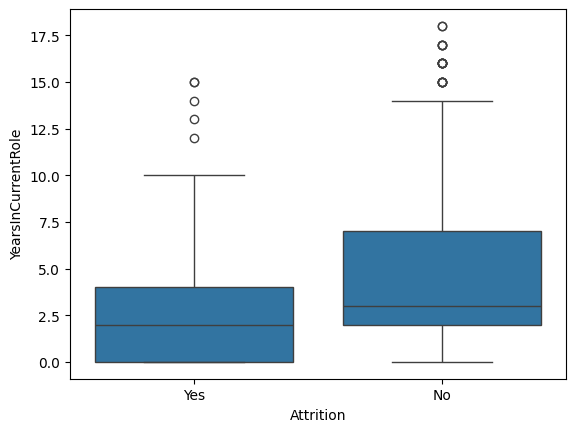

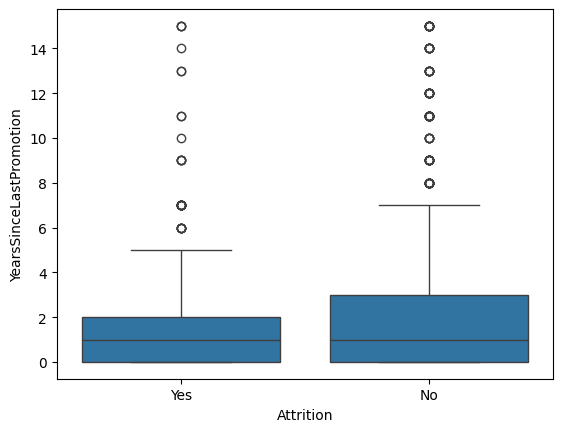

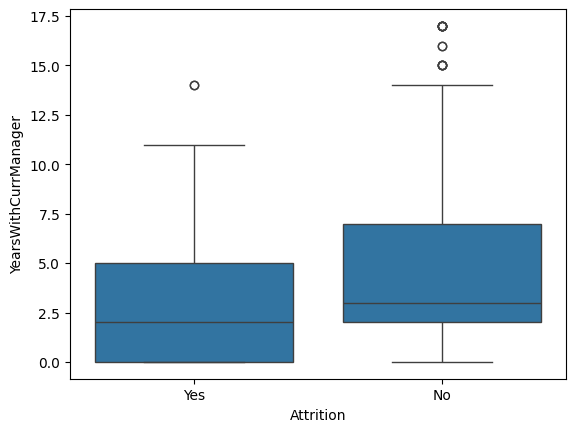

In [14]:
# Attrition vs categorical
for col in df.select_dtypes(include='object'):
    sns.countplot(x=col, hue='Attrition', data=df)
    plt.xticks(rotation=45)
    plt.show()

# Attrition vs numerical
for col in df.select_dtypes(include=np.number):
    sns.boxplot(x='Attrition', y=col, data=df)
    plt.show()

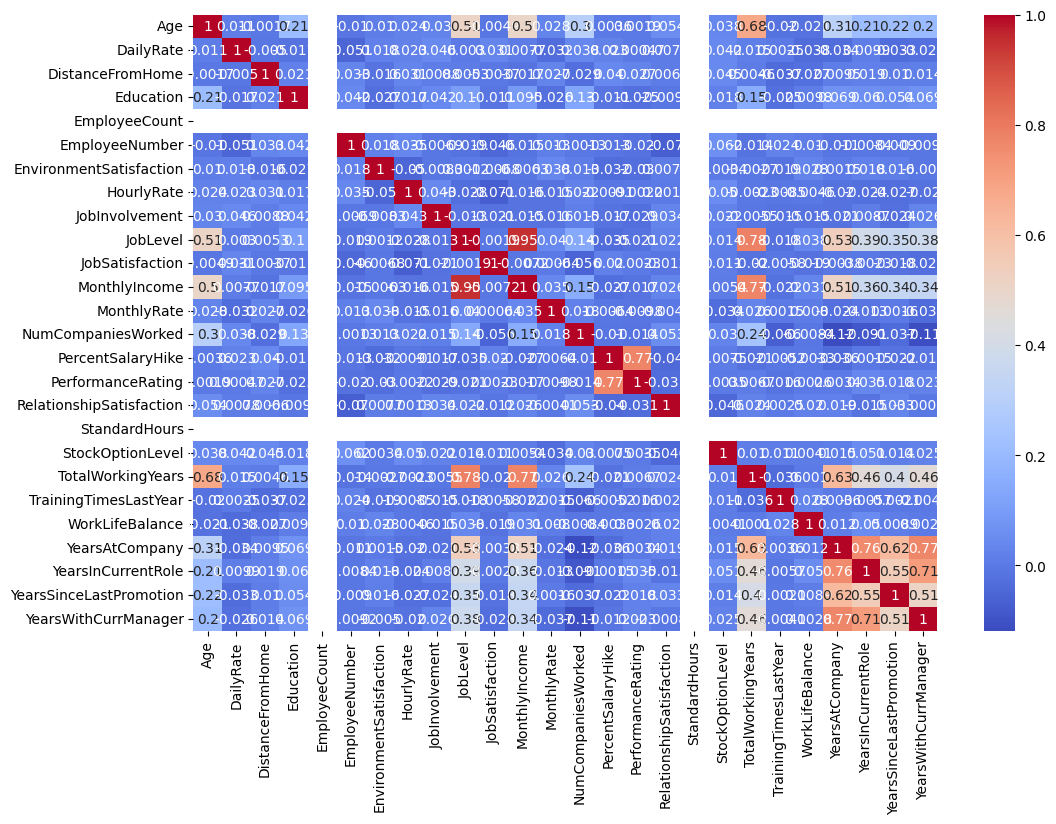

In [15]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

In [16]:
for col in df.select_dtypes(include=np.number):
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5*IQR
    upper = Q3 + 1.5*IQR

    df[col] = np.where(df[col] > upper, upper,
                       np.where(df[col] < lower, lower, df[col]))

In [17]:
le = LabelEncoder()
df['Attrition'] = le.fit_transform(df['Attrition'])

In [18]:
df = pd.get_dummies(df, drop_first=True)

In [44]:
X_pre_scale = df.drop('Attrition', axis=1)
y_unscaled = df['Attrition'] # Keep y unscaled for SMOTE

scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_pre_scale)
X_scaled_df = pd.DataFrame(X_scaled_array, columns=X_pre_scale.columns, index=X_pre_scale.index)

# Create a df_scaled where only X features are scaled, Attrition remains unscaled
df_scaled = X_scaled_df.copy()
df_scaled['Attrition'] = y_unscaled

In [35]:
X = df_scaled.drop('Attrition', axis=1)
y = df_scaled['Attrition'].astype(int) # Ensure y is explicitly integer type

In [45]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [36]:
smote = SMOTE()
X_train, y_train = smote.fit_resample(X_train, y_train)

In [37]:
models = {
    "Logistic": LogisticRegression(),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(),
    "KNN": KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred)
    }

    print(f"\n{name} Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Logistic Confusion Matrix:
 [[200  55]
 [ 17  22]]

Decision Tree Confusion Matrix:
 [[218  37]
 [ 28  11]]

Random Forest Confusion Matrix:
 [[250   5]
 [ 33   6]]

KNN Confusion Matrix:
 [[167  88]
 [ 15  24]]


In [38]:
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5)
    print(f"{name} CV Score:", scores.mean())

Logistic CV Score: 0.883673469387755
Decision Tree CV Score: 0.7761904761904762
Random Forest CV Score: 0.8598639455782312
KNN CV Score: 0.8489795918367345


In [39]:
param_grid = {
    'n_estimators': [50,100],
    'max_depth': [5,10]
}

grid = GridSearchCV(RandomForestClassifier(), param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

In [40]:
from scipy.stats import randint

param_dist = {
    'n_estimators': randint(50,200),
    'max_depth': randint(5,20)
}

rand = RandomizedSearchCV(RandomForestClassifier(), param_dist, n_iter=5, cv=3)
rand.fit(X_train, y_train)

RandomizedSearchCV(cv=3, estimator=RandomForestClassifier(), n_iter=5,
                   param_distributions={'max_depth': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78b57acf2a20>,
                                        'n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x78b577c00230>})

In [41]:
comparison = pd.DataFrame(results).T
print(comparison)

               Accuracy  Precision    Recall        F1   ROC-AUC
Logistic       0.755102   0.285714  0.564103  0.379310  0.674208
Decision Tree  0.778912   0.229167  0.282051  0.252874  0.568477
Random Forest  0.870748   0.545455  0.153846  0.240000  0.567119
KNN            0.649660   0.214286  0.615385  0.317881  0.635143


In [42]:
best_model = comparison['F1'].idxmax()
print("Best Model:", best_model)

Best Model: Logistic


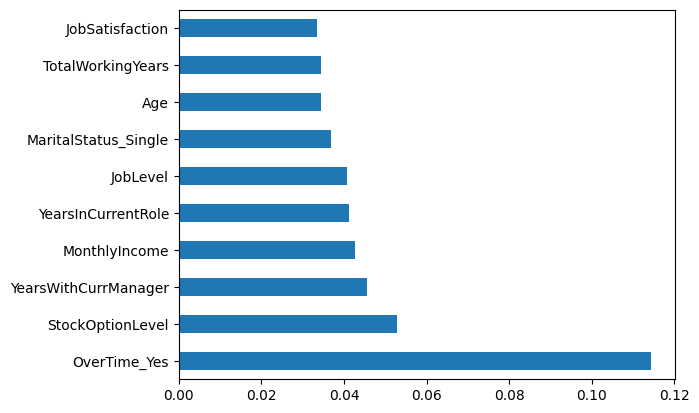

In [43]:
# Feature importance (for Random Forest)
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

importance = pd.Series(rf.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10).plot(kind='barh')
plt.show()

In [ ]:
# ✅ SAVE MODEL - Added automatically
import pickle

# Save the best model (Logistic Regression had best F1)
with open('model.pkl', 'wb') as f:
    pickle.dump(models['Logistic'], f)

# Save the scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Download both files to your computer
from google.colab import files
files.download('model.pkl')
files.download('scaler.pkl')

print('✅ model.pkl and scaler.pkl downloaded successfully!')